# Alignment quality scoring with `score_alignment`

After aligning two spatial transcriptomics datasets, we need quantitative metrics
to evaluate how good the alignment is. This notebook demonstrates
`sq.experimental.tl.score_alignment` on a real cross-technology alignment:

- **MERFISH** (Allen Brain Cell Atlas, section 38): 120k cells, 550 genes
- **Xenium** (10x Genomics, fresh-frozen mouse brain): 131k cells, 248 genes
- **90 shared genes** for expression-based metrics

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import squidpy as sq

plt.rcParams["figure.figsize"] = (12, 5)

/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/Users/selman/projects/squidpy/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  inner = partial(_inner_join_spatialelement_table)
/Users/selman/project

## Load data

In [2]:
adata_merfish = ad.read_h5ad("data/merfish_section38.h5ad")
adata_xenium = ad.read_h5ad("data/xenium_mouse_brain.h5ad")

shared_genes = sorted(set(adata_merfish.var_names) & set(adata_xenium.var_names))

print(f"MERFISH:       {adata_merfish.n_obs} cells x {adata_merfish.n_vars} genes")
print(f"Xenium:        {adata_xenium.n_obs} cells x {adata_xenium.n_vars} genes")
print(f"Shared genes:  {len(shared_genes)}")
print(f"  Examples: {shared_genes[:10]}")

cm = adata_merfish.obsm["spatial"]
cx = adata_xenium.obsm["spatial"]
print(f"\nMERFISH spatial: x=[{cm[:,0].min():.1f}, {cm[:,0].max():.1f}], y=[{cm[:,1].min():.1f}, {cm[:,1].max():.1f}]")
print(f"Xenium spatial:  x=[{cx[:,0].min():.1f}, {cx[:,0].max():.1f}], y=[{cx[:,1].min():.1f}, {cx[:,1].max():.1f}]")

MERFISH:       120186 cells x 550 genes
Xenium:        130870 cells x 248 genes
Shared genes:  90
  Examples: ['Acta2', 'Adamts2', 'Adamtsl1', 'Angpt1', 'Aqp4', 'Arhgap25', 'Bcl11b', 'Calb1', 'Calb2', 'Car4']

MERFISH spatial: x=[0.5, 10.6], y=[2.0, 8.6]
Xenium spatial:  x=[6.9, 10084.9], y=[188.5, 7032.0]


The MERFISH coordinates are in mm (~0--10) while Xenium is in microns
(~0--10,000). We rescale MERFISH to microns so OT can work on compatible
coordinate systems.

In [3]:
adata_merfish.obsm["spatial"] = adata_merfish.obsm["spatial"] * 1000.0

cm = adata_merfish.obsm["spatial"]
print(f"MERFISH rescaled: x=[{cm[:,0].min():.1f}, {cm[:,0].max():.1f}], y=[{cm[:,1].min():.1f}, {cm[:,1].max():.1f}]")

MERFISH rescaled: x=[533.3, 10605.8], y=[2029.4, 8589.3]


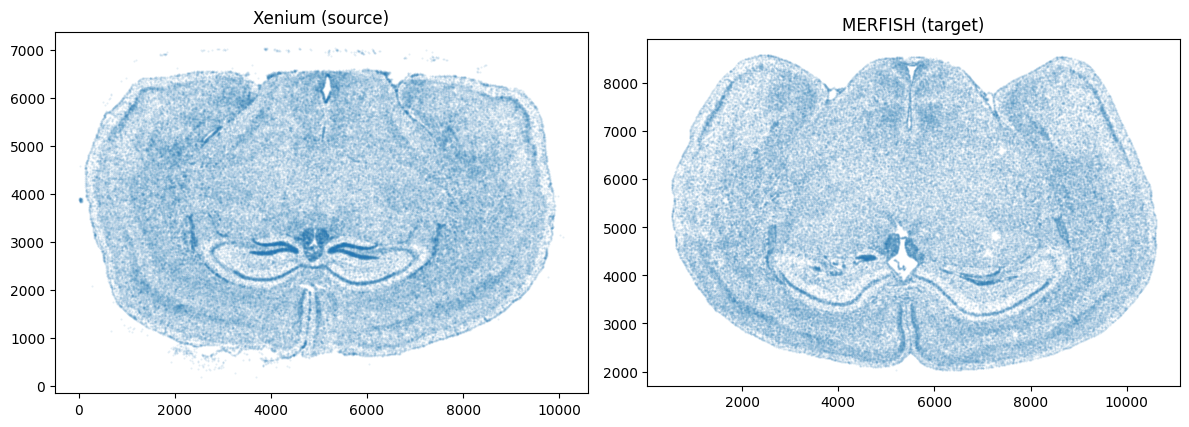

In [4]:
fig, axes = plt.subplots(1, 2)
for ax, ad_obj, title in [
    (axes[0], adata_xenium, "Xenium (source)"),
    (axes[1], adata_merfish, "MERFISH (target)"),
]:
    c = ad_obj.obsm["spatial"]
    ax.scatter(c[:, 0], c[:, 1], s=0.3, alpha=0.1)
    ax.set_aspect("equal")
    ax.set_title(title)
fig.tight_layout()

## Align with binned OT

In [5]:
sq.experimental.tl.align(
    adata_xenium,
    adata_merfish,
    method="optimal_transport",
    n_bins=(120, 100),
    verbose=True,
    solve_kwargs={"epsilon": 1e-2},
)

[ott-binned] Original: 130870 source + 120186 target = 251056 cells
[ott-binned] Binned:   10894 source bins (grid 120x120) + 8405 target bins (grid 100x100)
[ott-binned] Solving Sinkhorn on binned centroids ...
[ott] PointCloud: {'epsilon': 0.01, 'scale_cost': 'mean'}
[ott] solve:      (defaults)
[ott] Sinkhorn:   (defaults)
[ott] cost matrix: mean=1.0000  shape=(10894, 8405)  epsilon=0.010000
[ott] converged=True  iterations=110
[ott-binned] Computing transformation (mode='warp') ...
[ott-binned] Aligned coordinates stored in obsm['spatial_aligned']


/Users/selman/projects/squidpy/src/squidpy/experimental/tl/_align.py:1889: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


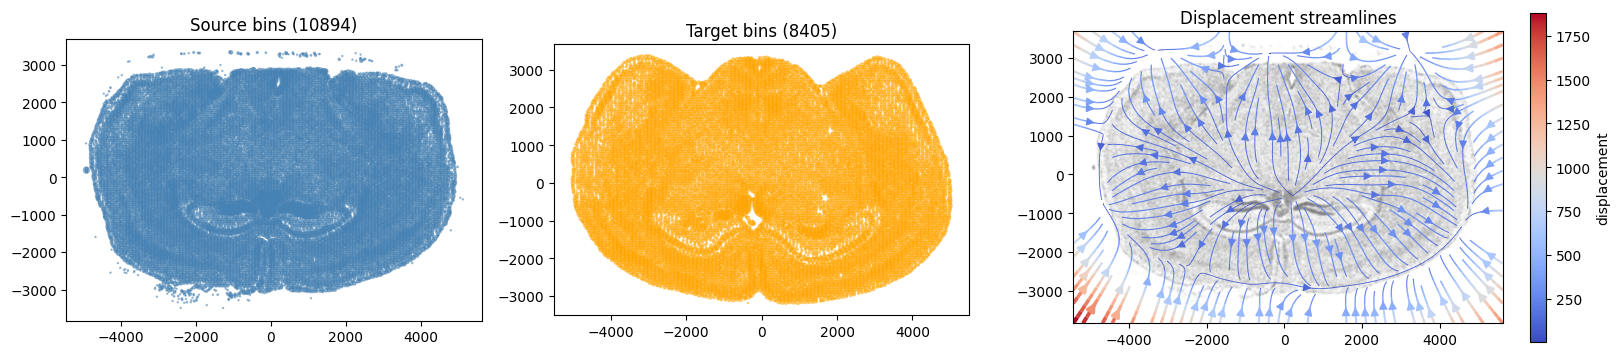

In [6]:
# All 5 panels (default)
adata_source, adata_target = adata_xenium, adata_merfish
sq.experimental.tl.plot_ot_alignment(adata_source, adata_target, panels=["bins", "stream"]);




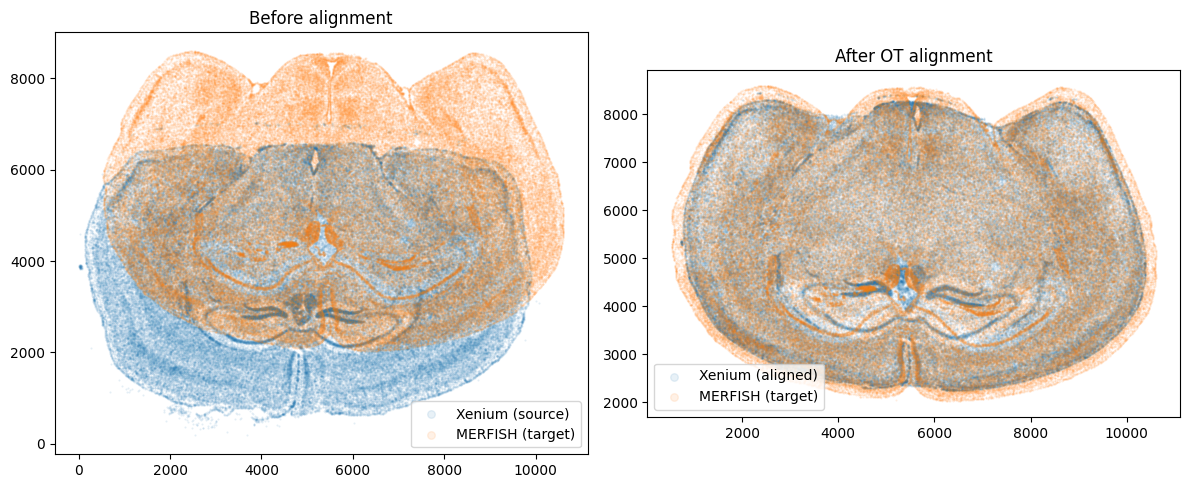

In [7]:
aligned = adata_xenium.obsm["spatial_aligned"]
merfish_coords = adata_merfish.obsm["spatial"]

fig, axes = plt.subplots(1, 2)
axes[0].scatter(adata_xenium.obsm["spatial"][:, 0], adata_xenium.obsm["spatial"][:, 1],
                s=0.3, alpha=0.1, label="Xenium (source)")
axes[0].scatter(merfish_coords[:, 0], merfish_coords[:, 1],
                s=0.3, alpha=0.1, label="MERFISH (target)")
axes[0].legend(markerscale=10)
axes[0].set_aspect("equal")
axes[0].set_title("Before alignment")

axes[1].scatter(aligned[:, 0], aligned[:, 1],
                s=0.3, alpha=0.1, label="Xenium (aligned)")
axes[1].scatter(merfish_coords[:, 0], merfish_coords[:, 1],
                s=0.3, alpha=0.1, label="MERFISH (target)")
axes[1].legend(markerscale=10)
axes[1].set_aspect("equal")
axes[1].set_title("After OT alignment")
fig.tight_layout()

/var/folders/xy/w8sj_5197yg42f3c2txh8gww0000gn/T/ipykernel_3426/80178832.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(markerscale=10)


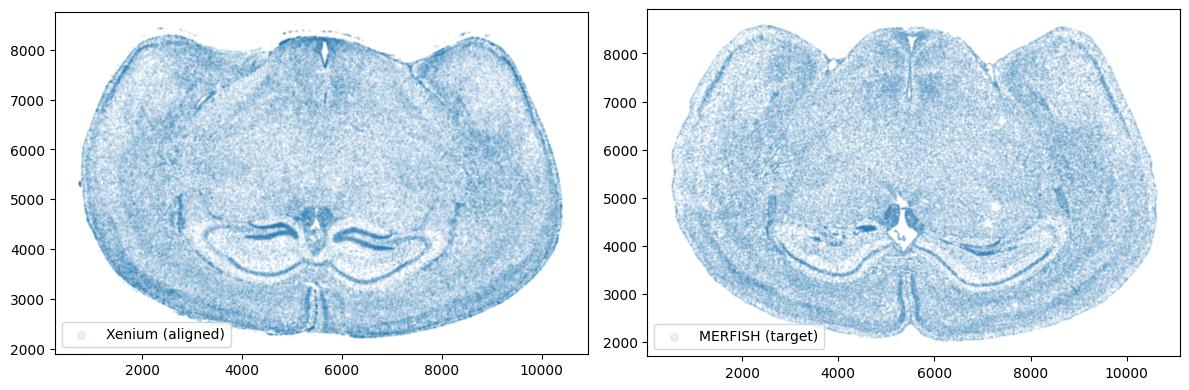

In [8]:
aligned = adata_xenium.obsm["spatial_aligned"]
merfish_coords = adata_merfish.obsm["spatial"]

fig, axes = plt.subplots(1, 2)

axes[0].legend(markerscale=10)
axes[0].set_aspect("equal")

axes[0].scatter(aligned[:, 0], aligned[:, 1],
                s=0.3, alpha=0.1, label="Xenium (aligned)")
axes[0].legend(markerscale=10)
axes[1].scatter(merfish_coords[:, 0], merfish_coords[:, 1],
                s=0.3, alpha=0.1, label="MERFISH (target)")
axes[1].legend(markerscale=10)
axes[1].set_aspect("equal")
fig.tight_layout()

## Score the alignment

| Metric | Range | Meaning |
|---|---|---|
| **coverage** | 0--1 | Fraction of target cells with a source neighbor within `radius` |
| **expr_knn_corr** | -1--1 | Median Pearson correlation between source cells and their target kNN expression |
| **expr_knn_cosine** | 0--1 | Same but with cosine similarity |

In [9]:
scores = sq.experimental.tl.score_alignment(
    adata_xenium,
    adata_merfish,
    k=10,
)

scores

[score_alignment] Alignment quality metrics:
  n_source:            130870
  n_target:            120186
  radius_used:         12.2347
  coverage:            0.7256
  mean_nn_dist:        17.2079
  median_nn_dist:      8.6814
  expr_knn_corr:       0.4728
  expr_knn_cosine:     0.6138


{'n_source': 130870,
 'n_target': 120186,
 'mean_nn_dist': 17.207864094073425,
 'median_nn_dist': 8.681362455850007,
 'radius_used': 12.234659556028939,
 'coverage': 0.7255836786314546,
 'n_genes_used': 90,
 'expr_knn_corr': 0.472830133556987,
 'expr_knn_cosine': 0.6137975160252314}